# The Phase Estimation Problem & Procedure

## Phase Estimation Problem

**Input:**  
A unitary quantum circuit for an *n*-qubit operation $U$ along with an *n*-qubit quantum state $|\psi\rangle$

**Promise:**  
$|\psi\rangle$ is an eigenvector of $U$

**Output:**  
An approximation to the number $\theta \in [0,1)$ satisfying $U|\psi\rangle = e^{2\pi i \theta} |\psi\rangle$

## Solving the Phase Estimation Problem: A simplified Case

**Promise:**

$\theta$ is either $0$ or $\frac{1}{2}$

**Output:**

- $\theta$ is $0 \rightarrow 0$

- $\theta$ is $\frac{1}{2} \rightarrow 1$

**Lambda values:**

- $e^{2\pi i 0} = 1$
- $e^{2\pi i \frac{1}{2}} = e^{\pi i} = -1$

**Example unitary matrix that yields the lambda values for ket0:**

- For $\theta = 0$:

$$
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

- For $\theta = \frac{1}{2}$:

$$
\begin{pmatrix}
-1 & 0 \\
0 & 1
\end{pmatrix}
$$

The following circuit implements the phase estimator for our simplified case:

<img src="./diagrams/simple-estimate-phase.svg" width="500" />

In [5]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate

In [9]:
def get_unitary(case: int):
    # Case 0: theta 0, Case 1: theta 1/2
    U = np.array([
        [1,0],
        [0,1]
    ])

    if case == 1:
        U[0][0] = -1

    gate = UnitaryGate(U)

    controlled_gate = gate.control()

    return controlled_gate

In [13]:
get_unitary(0)

Instruction(name='c-unitary', num_qubits=2, num_clbits=0, params=[array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])])

In [16]:
get_unitary(1)

Instruction(name='c-unitary', num_qubits=2, num_clbits=0, params=[array([[-1.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j]])])

In [14]:
def ket_zero_phase_estimator(case: int):
    # Case 0: theta 0, Case 1: theta 1/2
    
    qc = QuantumCircuit(2, 1)
    controlled_unitary = get_unitary(case)

    qc.h(0)
    qc.append(controlled_unitary, [0,1])
    qc.h(0)
    qc.measure(0, 0)

    return qc

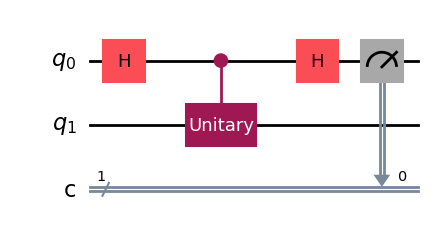

In [15]:
display(ket_zero_phase_estimator(0).draw(output="mpl"))

In [21]:
estimate_case = 1

In [22]:
from qiskit_aer import AerSimulator
from qiskit import transpile

sim = AerSimulator()

qc = ket_zero_phase_estimator(estimate_case)
qc_t = transpile(qc, sim)

result = sim.run(qc_t, shots=1, memory=True).result()
measurements = result.get_memory()
print(measurements)

['1']


The general phase estimation procedure with upto M qubits requires a **Quantum Fourier Transform (QFT)** Circuit. For each new control qubit added to the circuit the number of times the unitary operation is performed is doubled.

<img src="./diagrams/phase-estimation-procedure.svg" width="500" />